<a href="https://colab.research.google.com/github/matteogolfarelli/DataCentricAI/blob/main/Spatial_Modeling_of_Politics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [23]:
np.random.seed(42)

parties = {
    "Progressive":  np.array([2, 9, 8, 9, 9, 8, 3, 3, 8, 9]),
    "Conservative": np.array([9, 3, 4, 3, 3, 4, 9, 9, 4, 3]),
    "Liberal":      np.array([7, 5, 8, 6, 8, 5, 5, 8, 7, 5]),
    "Populist":     np.array([8, 7, 2, 4, 4, 7, 9, 6, 3, 6])
}
user =              np.array([6, 6, 7, 4, 5, 3, 4, 4, 7, 4])
labels = list(parties.keys()) + ["User"]
X = np.array(list(parties.values()) + [user])

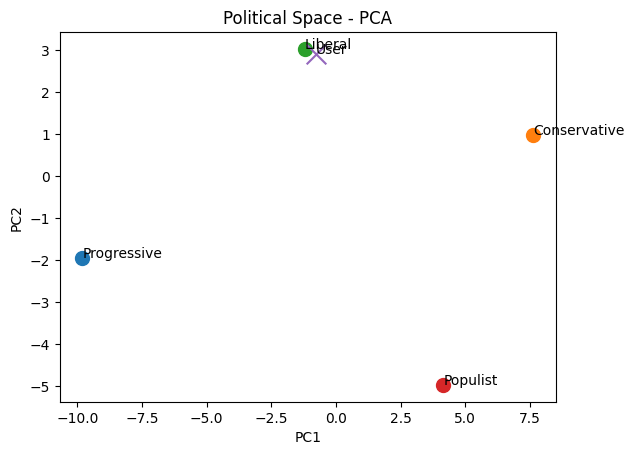

Explained variance: [0.71571895 0.19383102]


In [24]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure()
for i, label in enumerate(labels):
    marker = 'x' if label == "User" else 'o'
    size = 200 if label == "User" else 100
    plt.scatter(X_pca[i,0], X_pca[i,1], marker=marker, s=size)
    plt.text(X_pca[i,0], X_pca[i,1], label)
plt.title("Political Space - PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance:", pca.explained_variance_ratio_)

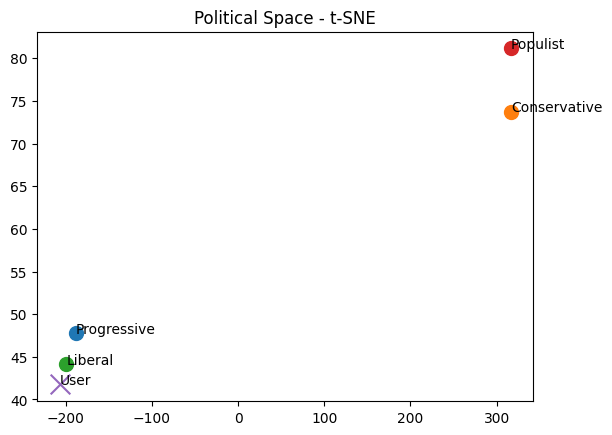

In [25]:
tsne = TSNE(n_components=2, perplexity=1, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure()
for i, label in enumerate(labels):
    marker = 'x' if label == "User" else 'o'
    size = 200 if label == "User" else 100
    plt.scatter(X_tsne[i,0], X_tsne[i,1], marker=marker, s=size)
    plt.text(X_tsne[i,0], X_tsne[i,1], label)

plt.title("Political Space - t-SNE")
plt.show()

In [26]:
from sklearn.metrics.pairwise import euclidean_distances
import pandas as pd

party_profiles = list(X)
party_names = list(labels)

distances = euclidean_distances(party_profiles)

distances_df = pd.DataFrame(distances, index=party_names, columns=party_names)
display(distances_df.round(2))

,Progressive,Conservative,Liberal,Populist,User
Progressive,0.00,17.69,10.30,14.35,10.95
Conservative,17.69,0.00,9.43,7.14,9.64
Liberal,10.30,9.43,0.00,10.10,6.16
Populist,14.35,7.14,10.10,0.00,9.80
User,10.95,9.64,6.16,9.80,0.00


10 randomly selected samples of X:


array([[ 8,  3,  6,  4,  3,  3,  6,  8,  4,  2],
       [ 8,  8,  1,  2,  5,  9,  7,  8,  3,  8],
       [ 4,  5,  4,  7,  9,  2,  4,  2,  7,  8],
       [ 8,  6,  4,  3,  2,  8,  8,  5,  1,  5],
       [ 7,  9,  3,  7,  6,  9,  7,  7,  3,  5],
       [ 9,  8,  2,  6,  3,  8,  7,  5,  1,  6],
       [ 2,  8,  6,  9,  8,  6,  2,  1, 10, 10],
       [ 7,  7,  9,  4, 10,  5,  6, 10,  5,  5],
       [ 4,  8,  8,  9,  8,  9,  3,  4,  7,  8],
       [ 3, 10,  7,  8,  7,  5,  6,  1,  8,  9]])


10 randomly selected labels of y:


array(['Conservative', 'Populist', 'Independent', 'Populist', 'Populist',
       'Populist', 'Progressive', 'Liberal', 'Progressive', 'Progressive'],
      dtype='<U12')

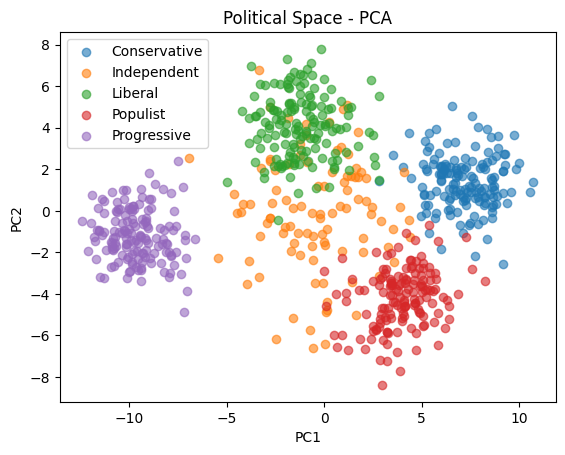

Explained variance (PCA): [0.5298842  0.15313032]


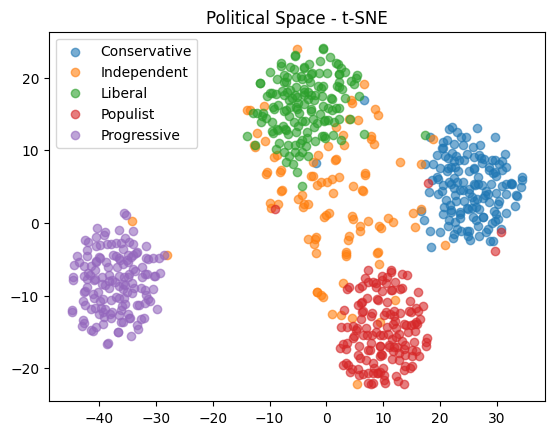

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

np.random.seed(42)

# -----------------------------
# 1. Define normalized party profiles
# -----------------------------
# Scale: 1 (low) → 10 (high)
# [low taxes, welfare, EU, environment, civil rights, public spending,
#  security, market, immigration, redistribution]

parties = {
    "Progressive": np.array([2, 9, 8, 9, 9, 8, 3, 3, 8, 9]),
    "Conservative": np.array([9, 3, 4, 3, 3, 4, 9, 9, 4, 3]),
    "Liberal":     np.array([7, 5, 8, 6, 8, 5, 5, 8, 7, 5]),
    "Populist":    np.array([8, 7, 2, 4, 4, 7, 9, 6, 3, 6])
}

# -----------------------------
# 2. Generate synthetic citizens
# -----------------------------
def generate_citizens(parties, n_per_party=150, noise_std=1.5):
    X, y = [], []
    for name, profile in parties.items():
        for _ in range(n_per_party):
            citizen = profile + np.round(np.random.normal(0, noise_std, size=profile.shape)).astype(int)
            citizen = np.clip(citizen, 1, 10)
            X.append(citizen)
            y.append(name)
    return np.array(X), np.array(y)

X_citizens, y_citizens = generate_citizens(parties)

# -----------------------------
# 3. Generate independent citizens
# -----------------------------
def generate_independents(n=100):
    return  np.round(np.random.uniform(1, 10, size=(n, 10))).astype(int)

X_ind = generate_independents(100)
y_ind = np.array(["Independent"] * len(X_ind))

# -----------------------------
# 4. Build final dataset
# -----------------------------
X = np.vstack([X_citizens, X_ind, list(parties.values())])
y = np.concatenate([y_citizens, y_ind, list(parties.keys())])

# Randomly select 10 samples to display
random_indices = np.random.choice(len(X), 10, replace=False)
print('10 randomly selected samples of X:')
display(X[random_indices])
print('\n10 randomly selected labels of y:')
display(y[random_indices])


# -----------------------------
# 5. PCA projection
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure()
for label in np.unique(y):
    idx = y == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, alpha=0.6)
plt.legend()
plt.title("Political Space - PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance (PCA):", pca.explained_variance_ratio_)

# -----------------------------
# 6. t-SNE projection
# -----------------------------
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure()
for label in np.unique(y):
    idx = y == label
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=label, alpha=0.6)
plt.legend()
plt.title("Political Space - t-SNE")
plt.show()